# Анализ аудиомоделей / Audio Models Analysis

Ноутбук загружает обученные аудиомодели классификации эмоций речи и оценивает их
на тестовом наборе данных **Dusha** (`combine_balanced_test.lmdb`).

Для каждой модели выводятся:
- Сводные метрики (Accuracy, Balanced Accuracy, F1, MCC, ROC-AUC)
- Отчёт по классам (Precision / Recall / F1)
- Матрица ошибок (confusion matrix)

**Эмоции (4 класса):** `angry` · `sad` · `neutral` · `positive`

---
## Содержание

| # | Модель | Описание |
|---|--------|----------|
| 1 | [Logistic Regression](#1-logistic-regression) | MFCC + sklearn LogReg (baseline) |
| 2 | [SVM](#2-svm) | MFCC + SVM (RBF kernel) |
| 3 | [Random Forest](#3-random-forest) | MFCC + ансамбль решающих деревьев |
| 4 | [OpenSmile XGBoost](#4-opensmile-xgboost) | OpenSMILE eGeMAPS + XGBoost/LightGBM |
| 5 | [CNN](#5-cnn) | Спектрограмма + свёрточная нейросеть |
| 6 | [CNN + BiLSTM](#6-cnn--bilstm) | Спектрограмма + CNN + рекуррентная сеть |
| 7 | [Wav2Vec2 XLSR-300M](#7-wav2vec2-xlsr-300m--self-attention) | Raw waveform + предобученный трансформер |

In [2]:
import sys
from pathlib import Path

for _p in [Path.cwd()] + list(Path.cwd().parents):
    if _p.name == 'my_experiments':
        if str(_p.parent) not in sys.path:
            sys.path.append(str(_p.parent))
        break

from my_experiments.utils.config_utils import (
    PROJECT_ROOT, DATASET_PATH, TARGET_NAMES,
)

import numpy as np
import torch
import warnings
warnings.filterwarnings('ignore')

AGGREGATED_DIR = DATASET_PATH / 'processed_dataset_090' / 'aggregated_dataset'

# ──────────────────────────────────────────────────────
# ВЫБОР ТЕСТОВОГО НАБОРА ДАННЫХ
# Раскомментируйте нужный путь:
# ──────────────────────────────────────────────────────
# TEST_LMDB = AGGREGATED_DIR / 'combine_balanced_test.lmdb'        # полный сбалансированный тест
# TEST_LMDB = AGGREGATED_DIR / 'combine_balanced_test_small.lmdb'  # малая версия
# TEST_LMDB = AGGREGATED_DIR / 'dusha_resd_test.lmdb'             # Dusha + RESD
# TEST_LMDB = AGGREGATED_DIR / 'crowd_test.lmdb'                  # только crowd
# TEST_LMDB = AGGREGATED_DIR / 'podcast_test.lmdb'                # только podcast
TEST_LMDB = AGGREGATED_DIR / 'combine_balanced_test.lmdb'

CHECKPOINTS_DIR = PROJECT_ROOT / 'my_experiments' / 'checkpoints' / 'audio'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Test dataset: {TEST_LMDB}')
print(f'Exists: {TEST_LMDB.exists()}')
print(f'Device: {DEVICE}')
print(f'Checkpoints: {CHECKPOINTS_DIR}')

Test dataset: /home/natlis/PycharmProjects/dusha_new/dusha/data_processing/dataset/processed_dataset_090/aggregated_dataset/combine_balanced_test.lmdb
Exists: True
Device: cpu
Checkpoints: /home/natlis/PycharmProjects/dusha_new/dusha/my_experiments/checkpoints/audio


---
## Вспомогательные функции

In [3]:
import pickle
import lmdb

from my_experiments.utils.lmdb_utils import open_lmdb_readonly, get_lmdb_length, parse_label_to_index
from my_experiments.utils.model_io import load_sklearn_model, load_pytorch_model
from my_experiments.utils.metrics import print_eval_block, compute_classification_metrics


def _to_fixed_vector(feat: np.ndarray) -> np.ndarray:
    arr = np.asarray(feat)
    if arr.ndim == 1:
        return arr.astype(np.float32)
    mean_part = arr.mean(axis=-1).reshape(-1)
    std_part = arr.std(axis=-1).reshape(-1)
    return np.concatenate([mean_part, std_part]).astype(np.float32)


def load_features_for_sklearn(lmdb_path):
    from my_experiments.utils.lmdb_utils import load_feature_vectors_from_lmdb
    return load_feature_vectors_from_lmdb(
        lmdb_path=Path(lmdb_path),
        vectorize_fn=_to_fixed_vector,
        label_kind='emotion',
    )


def evaluate_sklearn(model, scaler, X_test, y_test):
    X_test_scaled = scaler.transform(X_test)
    y_pred = model.predict(X_test_scaled)
    
    has_proba = hasattr(model, 'predict_proba')
    probs = model.predict_proba(X_test_scaled) if has_proba else None
    
    y_true_num = np.array([parse_label_to_index(l) for l in y_test])
    y_pred_num = np.array([parse_label_to_index(l) for l in y_pred])
    
    metrics = compute_classification_metrics(y_true_num, y_pred_num, probs)
    return metrics, y_true_num, y_pred_num

---
## 1. Logistic Regression

**Тип:** Базовый sklearn-классификатор  
**Признаки:** MFCC (mean+std per frame)  
**Чекпоинт:** `logictic_regressoin_combine_balanced_train_small_model.pkl`

✓ Модель загружена из /home/natlis/PycharmProjects/dusha_new/dusha/my_experiments/checkpoints/audio/logictic_regressoin_combine_balanced_train_small_model.pkl
✓ Scaler загружен из /home/natlis/PycharmProjects/dusha_new/dusha/my_experiments/checkpoints/audio/logictic_regressoin_combine_balanced_train_small_scaler.pkl

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Logistic Regression - Test Metrics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Overall Metrics:


,Metric,Value
0,Accuracy,0.4634
1,Balanced Accuracy,0.4469
2,Precision (macro),0.4656
3,Recall (macro),0.4469
4,F1 (macro),0.4516
5,F1 (weighted),0.4622
6,MCC,0.2670
7,ROC-AUC (OvR macro),0.4735


Per-Class Report:


,Class,Precision,Recall,F1-Score,Support
0,angry,0.4789,0.3303,0.3910,1338
1,sad,0.5501,0.5906,0.5696,2157
2,neutral,0.3422,0.4134,0.3745,1681
3,positive,0.4911,0.4531,0.4713,1216


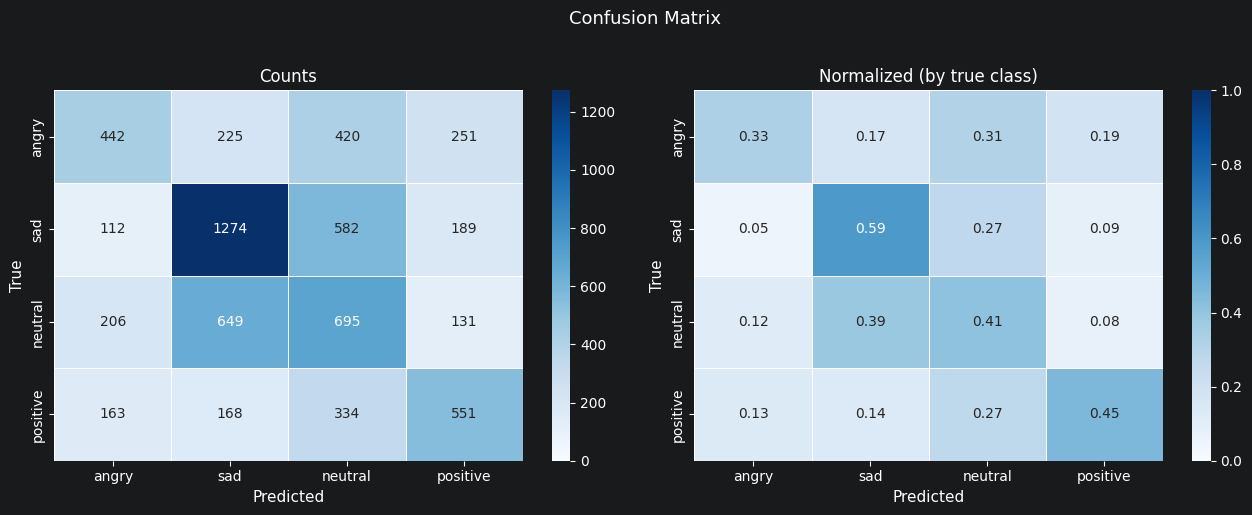

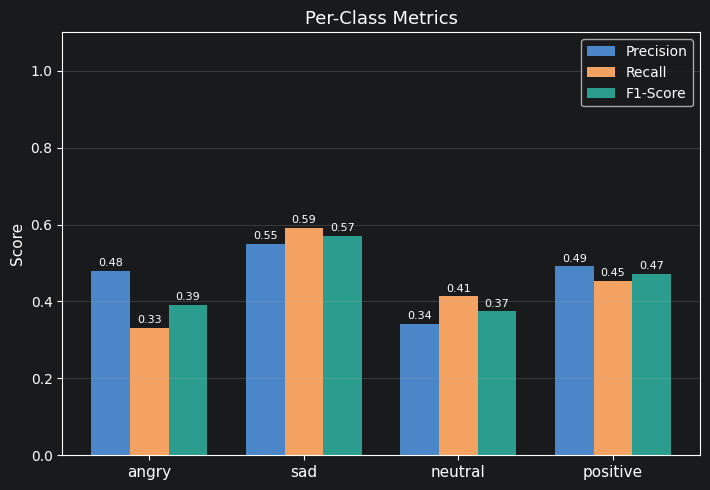

In [4]:
dataset_name = 'combine_balanced_train_small'
model_lr, scaler_lr = load_sklearn_model(
    dataset_name, models_dir=CHECKPOINTS_DIR, model_name='logictic_regressoin'
)
X_test_lr, y_test_lr = load_features_for_sklearn(TEST_LMDB)
metrics_lr, yt_lr, yp_lr = evaluate_sklearn(model_lr, scaler_lr, X_test_lr, y_test_lr)
print_eval_block('Logistic Regression - Test Metrics', metrics_lr, yt_lr, yp_lr)

---
## 2. SVM

**Тип:** Support Vector Machine (RBF kernel)  
**Признаки:** MFCC (mean+std per frame)  
**Чекпоинт:** `svm_combine_balanced_train_model.pkl`

✓ Модель загружена из /home/natlis/PycharmProjects/dusha_new/dusha/my_experiments/checkpoints/audio/svm_combine_balanced_train_model.pkl
✓ Scaler загружен из /home/natlis/PycharmProjects/dusha_new/dusha/my_experiments/checkpoints/audio/svm_combine_balanced_train_scaler.pkl

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SVM - Test Metrics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Overall Metrics:


,Metric,Value
0,Accuracy,0.4970
1,Balanced Accuracy,0.4759
2,Precision (macro),0.5054
3,Recall (macro),0.4759
4,F1 (macro),0.4825
5,F1 (weighted),0.4947
6,MCC,0.3118
7,ROC-AUC (OvR macro),N/A


Per-Class Report:


,Class,Precision,Recall,F1-Score,Support
0,angry,0.5434,0.3371,0.4161,1338
1,sad,0.5875,0.6583,0.6209,2157
2,neutral,0.3512,0.4337,0.3881,1681
3,positive,0.5398,0.4745,0.5050,1216


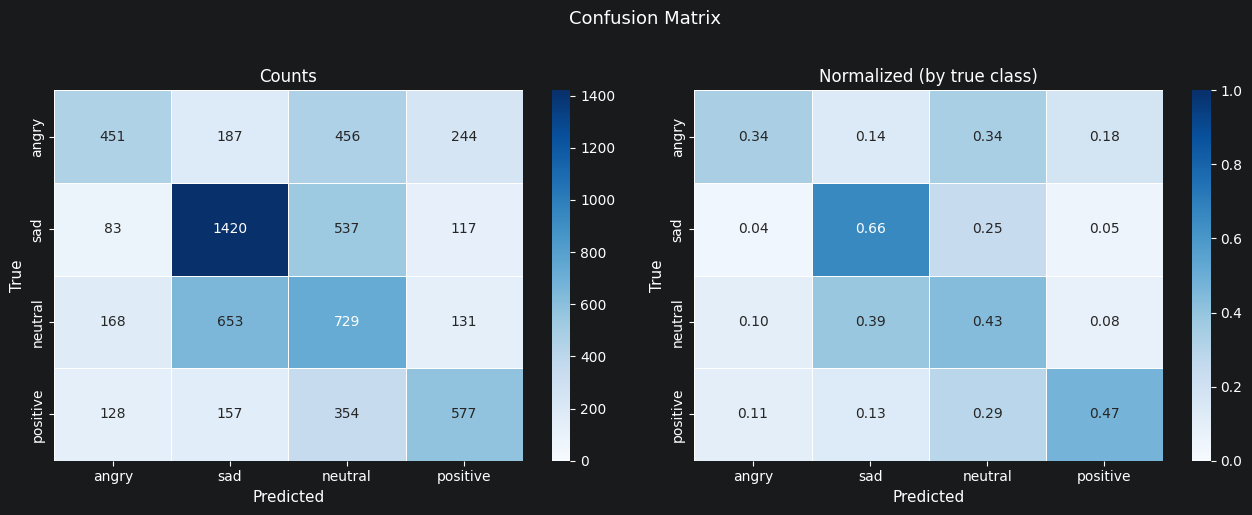

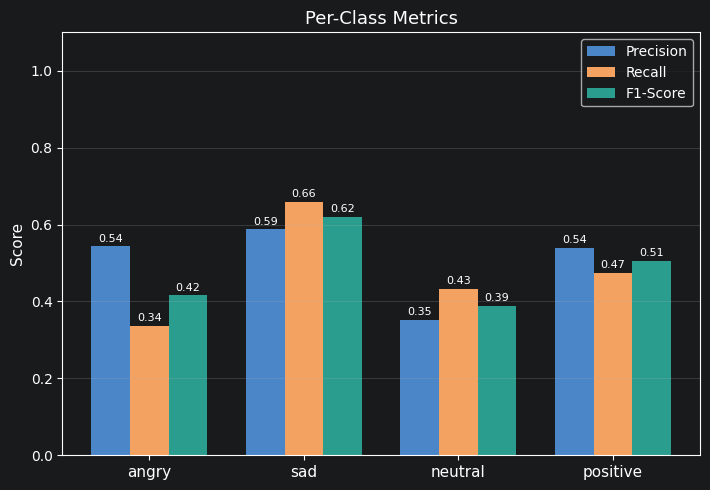

In [5]:
dataset_name = 'combine_balanced_train'
model_svm, scaler_svm = load_sklearn_model(
    dataset_name, models_dir=CHECKPOINTS_DIR, model_name='svm'
)
X_test_svm, y_test_svm = load_features_for_sklearn(TEST_LMDB)
metrics_svm, yt_svm, yp_svm = evaluate_sklearn(model_svm, scaler_svm, X_test_svm, y_test_svm)
print_eval_block('SVM - Test Metrics', metrics_svm, yt_svm, yp_svm)

---
## 3. Random Forest

**Тип:** Ансамбль решающих деревьев  
**Признаки:** MFCC (mean+std per frame)  
**Чекпоинт:** `random_forest_combine_balanced_train_model.pkl`

✓ Модель загружена из /home/natlis/PycharmProjects/dusha_new/dusha/my_experiments/checkpoints/audio/random_forest_combine_balanced_train_model.pkl
✓ Scaler загружен из /home/natlis/PycharmProjects/dusha_new/dusha/my_experiments/checkpoints/audio/random_forest_combine_balanced_train_scaler.pkl

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Random Forest - Test Metrics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Overall Metrics:


[Parallel(n_jobs=22)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=22)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=22)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=22)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=22)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=22)]: Done 100 out of 100 | elapsed:    0.0s finished


,Metric,Value
0,Accuracy,0.4640
1,Balanced Accuracy,0.4409
2,Precision (macro),0.4729
3,Recall (macro),0.4409
4,F1 (macro),0.4475
5,F1 (weighted),0.4616
6,MCC,0.2661
7,ROC-AUC (OvR macro),0.4795


Per-Class Report:


,Class,Precision,Recall,F1-Score,Support
0,angry,0.4963,0.3004,0.3743,1338
1,sad,0.5609,0.6194,0.5887,2157
2,neutral,0.3300,0.4349,0.3753,1681
3,positive,0.5046,0.4087,0.4516,1216


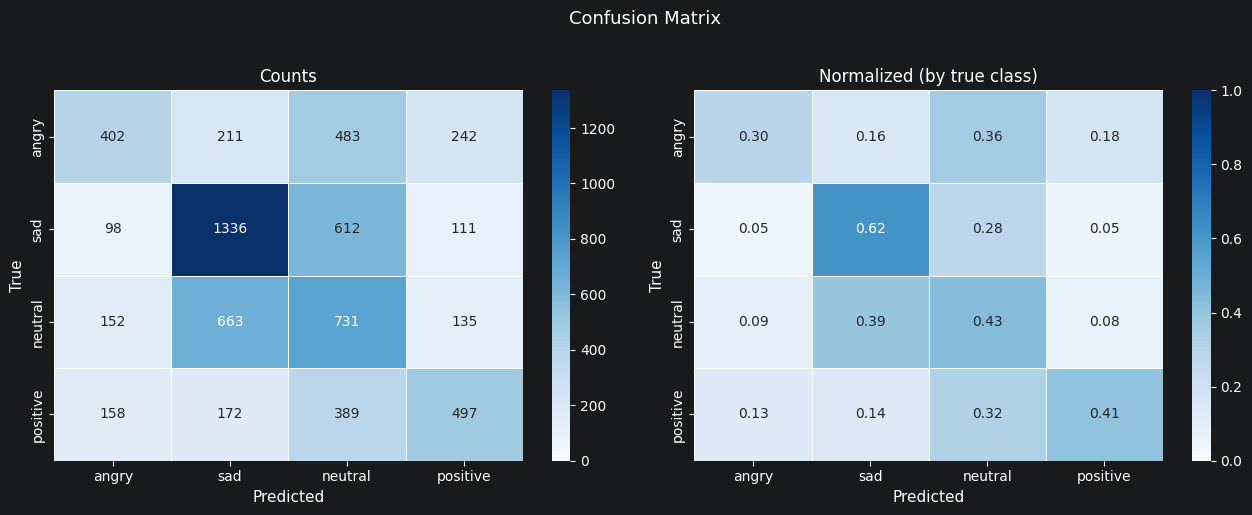

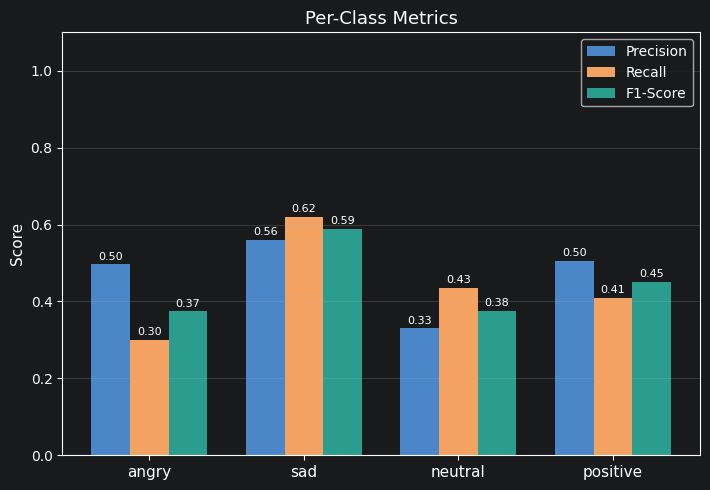

In [6]:
dataset_name = 'combine_balanced_train'
model_rf, scaler_rf = load_sklearn_model(
    dataset_name, models_dir=CHECKPOINTS_DIR, model_name='random_forest'
)
X_test_rf, y_test_rf = load_features_for_sklearn(TEST_LMDB)
metrics_rf, yt_rf, yp_rf = evaluate_sklearn(model_rf, scaler_rf, X_test_rf, y_test_rf)
print_eval_block('Random Forest - Test Metrics', metrics_rf, yt_rf, yp_rf)

---
## 4. OpenSmile XGBoost

**Тип:** Градиентный бустинг (XGBoost/LightGBM)  
**Признаки:** OpenSMILE eGeMAPS (88 признаков), извлекаются из WAV-файлов  
**Чекпоинт:** `openSmile_XGBoost_combine_balanced_train_model.pkl`  
**Примечание:** Требует OpenSMIME и доступ к исходным WAV-файлам.

In [ ]:
import joblib

model_xgb_path = CHECKPOINTS_DIR / 'openSmile_XGBoost_combine_balanced_train_model.pkl'
model_xgb = joblib.load(model_xgb_path)
print(f'XGBoost model loaded: {model_xgb_path}')
print(f'Model type: {type(model_xgb).__name__}')

X_test_xgb, y_test_xgb = load_features_for_sklearn(TEST_LMDB)

y_pred_xgb_str = model_xgb.predict(X_test_xgb)
probs_xgb = model_xgb.predict_proba(X_test_xgb) if hasattr(model_xgb, 'predict_proba') else None

y_true_xgb = np.array([parse_label_to_index(l) for l in y_test_xgb])
y_pred_xgb = np.array([parse_label_to_index(l) for l in y_pred_xgb_str])

metrics_xgb = compute_classification_metrics(y_true_xgb, y_pred_xgb, probs_xgb)
print_eval_block('OpenSmile XGBoost - Test Metrics', metrics_xgb, y_true_xgb, y_pred_xgb)

---
## 5. CNN

**Тип:** Свёрточная нейронная сеть  
**Архитектура:** 3× Conv2D → AdaptiveAvgPool → Linear  
**Признаки:** Спектрограмма (из LMDB ключ 'x')  
**Чекпоинт:** `CNN_combine_balanced_train_model.pt`

✓ Checkpoint загружен из /home/natlis/PycharmProjects/dusha_new/dusha/my_experiments/checkpoints/audio/CNN_combine_balanced_train_model.pt

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  CNN - Test Metrics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Overall Metrics:


,Metric,Value
0,Loss,0.9623
1,Accuracy,0.5959
2,Balanced Accuracy,0.5775
3,F1 (macro),0.5847
4,F1 (weighted),0.5961
5,Precision (macro),0.6000
6,Recall (macro),0.5775
7,Wa,0.5775
8,ROC-AUC (OvR macro),0.8323


Per-Class Report:


,Class,Precision,Recall,F1-Score,Support
0,angry,0.6169,0.5561,0.5849,1338
1,sad,0.6840,0.7144,0.6989,2157
2,neutral,0.4684,0.5592,0.5098,1681
3,positive,0.6307,0.4803,0.5453,1216


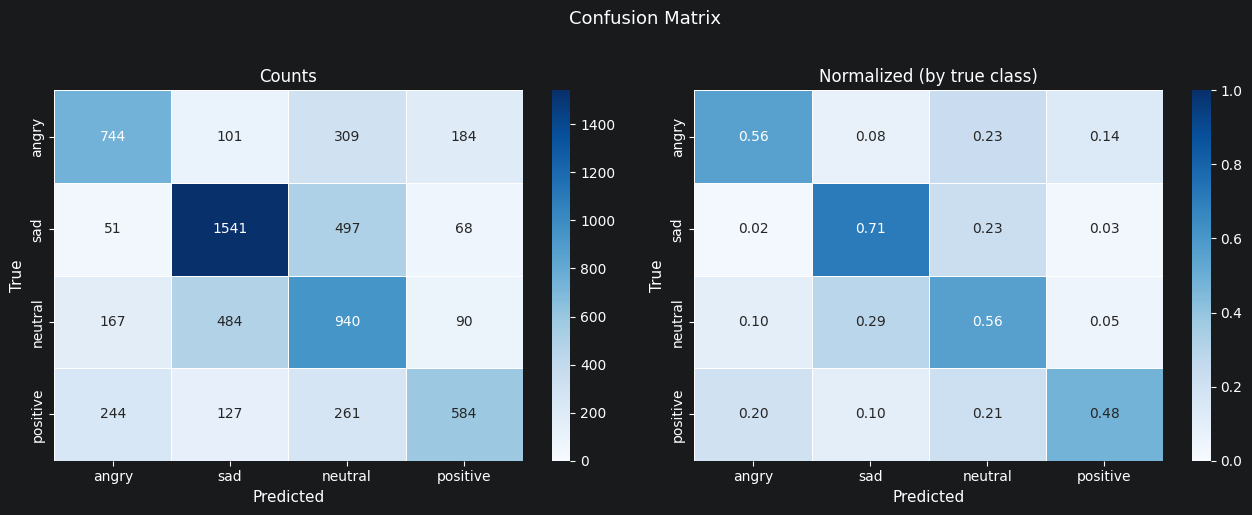

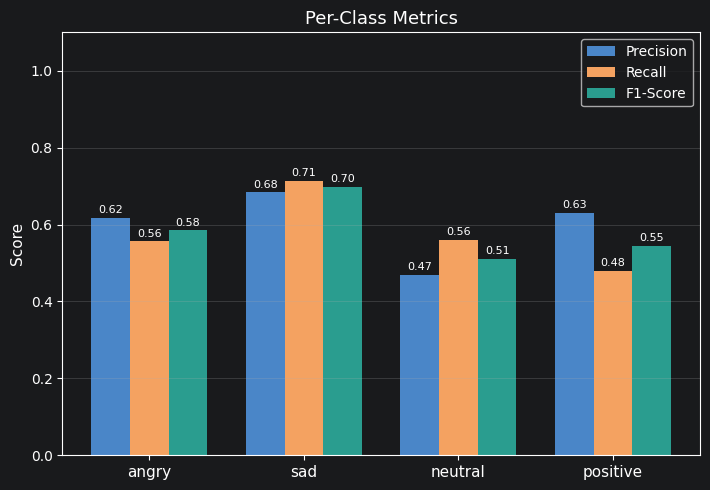

In [8]:
from torch import nn
from torch.utils.data import DataLoader
from my_experiments.audio_models.CNN.CNN import EmotionCNN, LmdbFeaturesDataset, pad_collate_fn, evaluate_split

checkpoint_cnn = load_pytorch_model(
    'combine_balanced_train', models_dir=CHECKPOINTS_DIR, model_name='CNN', map_location=DEVICE
)
model_cnn = EmotionCNN(n_classes=4)
model_cnn.load_state_dict(checkpoint_cnn['model_state_dict'])
model_cnn.to(DEVICE)
model_cnn.eval()

test_ds_cnn = LmdbFeaturesDataset(TEST_LMDB)
test_loader_cnn = DataLoader(test_ds_cnn, batch_size=32, shuffle=False, collate_fn=pad_collate_fn, num_workers=0)
criterion = nn.CrossEntropyLoss()

metrics_cnn, yt_cnn, yp_cnn, probs_cnn, _ = evaluate_split(model_cnn, test_loader_cnn, criterion, DEVICE)
print_eval_block('CNN - Test Metrics', metrics_cnn, yt_cnn, yp_cnn)

---
## 6. CNN + BiLSTM

**Тип:** Свёрточная + рекуррентная нейронная сеть  
**Архитектура:** 3× Conv2D → BiLSTM → Linear  
**Признаки:** Спектрограмма (из LMDB ключ 'x')  
**Чекпоинт:** `CNN_BiLSTM_combine_balanced_train_model.pt`

✓ Checkpoint загружен из /home/natlis/PycharmProjects/dusha_new/dusha/my_experiments/checkpoints/audio/CNN_BiLSTM_combine_balanced_train_model.pt

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  CNN+BiLSTM - Test Metrics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Overall Metrics:


,Metric,Value
0,Loss,0.6622
1,Accuracy,0.7517
2,Balanced Accuracy,0.7419
3,F1 (macro),0.7436
4,F1 (weighted),0.7498
5,Precision (macro),0.7470
6,Recall (macro),0.7419
7,Wa,0.7419
8,Uar,0.7419
9,MCC,0.6624


Per-Class Report:


,Class,Precision,Recall,F1-Score,Support
0,angry,0.7671,0.7975,0.7820,1338
1,sad,0.7934,0.8475,0.8195,2157
2,neutral,0.6832,0.6490,0.6656,1681
3,positive,0.7445,0.6735,0.7073,1216


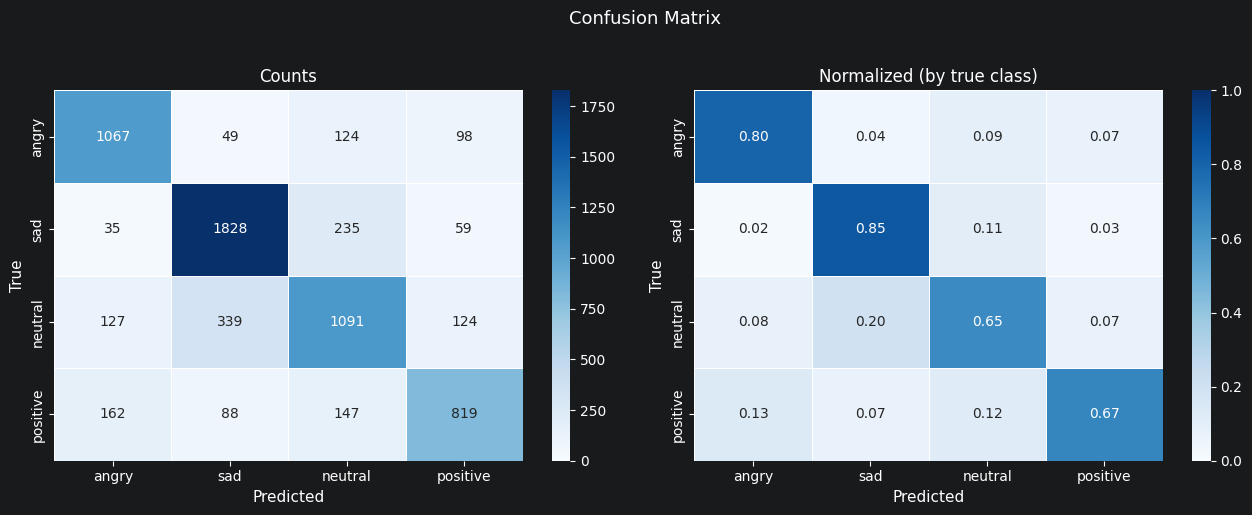

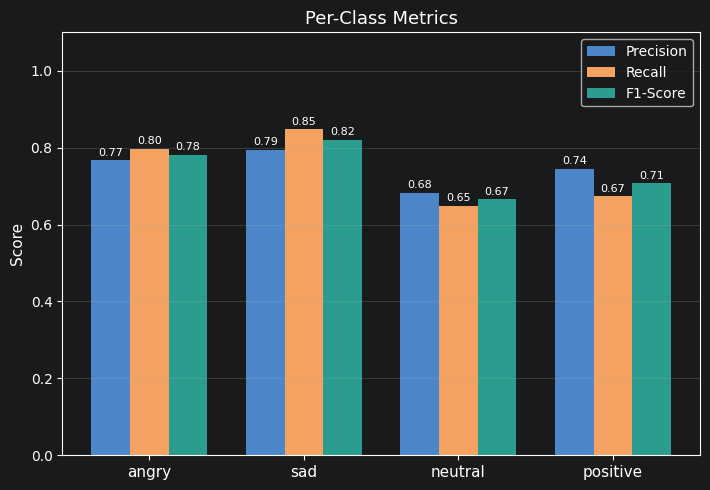

In [9]:
from my_experiments.audio_models.CNN.CNN_BiLSTM import EmotionCNNBiLSTM, evaluate_split, pad_collate_fn as pad_collate_bilstm

checkpoint_cnnbilstm = load_pytorch_model(
    'combine_balanced_train', models_dir=CHECKPOINTS_DIR, model_name='CNN_BiLSTM', map_location=DEVICE
)
model_cnnbilstm = EmotionCNNBiLSTM(n_classes=4)
model_cnnbilstm.load_state_dict(checkpoint_cnnbilstm['model_state_dict'])
model_cnnbilstm.to(DEVICE)
model_cnnbilstm.eval()

test_ds_cb = LmdbFeaturesDataset(TEST_LMDB)
test_loader_cb = DataLoader(test_ds_cb, batch_size=32, shuffle=False, collate_fn=pad_collate_bilstm, num_workers=0)
criterion = nn.CrossEntropyLoss()

metrics_cb, yt_cb, yp_cb, probs_cb, _ = evaluate_split(model_cnnbilstm, test_loader_cb, criterion, DEVICE)
print_eval_block('CNN+BiLSTM - Test Metrics', metrics_cb, yt_cb, yp_cb)

---
## 7. wav2vec2 XLSR-300M + Self-Attention

**Тип:** Предобученный трансформер (Wav2Vec2-XLSR-300M) + Attention Pooling  
**Признаки:** Raw waveform (из LMDB ключ 'waveform')  
**Чекпоинт:** `wav2vec2_xlsr300m_self_attention_combine_balanced_train_small_model.pt`  
**Примечание:** Требует доступа к HuggingFace для загрузки Wav2Vec2-модели.

In [ ]:
from my_experiments.audio_models.transformers.wav2vec_self_attention import (
    Wav2VecSelfAttentionClassifier, LmdbWaveDataset, wave_collate_fn, evaluate_split as wav2vec_evaluate_split,
)

checkpoint_w2v = load_pytorch_model(
    'combine_balanced_train_small', models_dir=CHECKPOINTS_DIR,
    model_name='wav2vec2_xlsr300m_self_attention', map_location=DEVICE
)
print(f'Model architecture params: {checkpoint_w2v.get("model_params", {})}')

model_w2v = Wav2VecSelfAttentionClassifier(
    pretrained_name='facebook/wav2vec2-xls-r-300m',
    n_classes=4,
    pooling_type='mean',
)
model_w2v.load_state_dict(checkpoint_w2v['model_state_dict'])
model_w2v.to(DEVICE)
model_w2v.eval()

test_ds_w2v = LmdbWaveDataset(TEST_LMDB, is_train=False, min_crop_sec=5.0, max_crop_sec=6.0)
test_loader_w2v = DataLoader(test_ds_w2v, batch_size=8, shuffle=False, collate_fn=wave_collate_fn, num_workers=0)
criterion = nn.CrossEntropyLoss()

if DEVICE == 'cpu':
    import time
    _t0 = time.time()
    print(f'\n⚠ Running on CPU — expect ~30-60 min for {len(test_ds_w2v)} samples.\n')

metrics_w2v, yt_w2v, yp_w2v, probs_w2v, _ = wav2vec_evaluate_split(
    model_w2v, test_loader_w2v, criterion, DEVICE, use_amp=False
)

if DEVICE == 'cpu':
    print(f'\n⏱ Evaluation took {time.time() - _t0:.0f}s')

print_eval_block('Wav2Vec2 XLSR-300M + Self-Attention - Test Metrics', metrics_w2v, yt_w2v, yp_w2v)